In [2]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
from TraceSimulator import NoiseGenerator
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from tqdm import tqdm
import h5py
import numpy as np
import matplotlib.pyplot as plt

# -------------------
# Load simulator config (one dict, reusable)
# -------------------
def read_yaml_to_dict(file_path):
    with open(file_path, "r") as file:
        return yaml.safe_load(file)




In [3]:
CONFIG_PATH = "/home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml"
CONFIG = read_yaml_to_dict(CONFIG_PATH)
ts = LongTraceSimulator(CONFIG)

In [2]:
# Load trace from saved h5 file
with h5py.File('/home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/trace_sample.h5', 'r') as hf:
    trace = hf['trace'][:]
    position = hf['position'][:]
    x, y, z = position[0], position[1], position[2]


In [9]:
trace=ts.generate(7500, x=0, y=0, z=-1700,type_recoil='ER')
trace=trace[0]
trace.shape

(56, 32768)

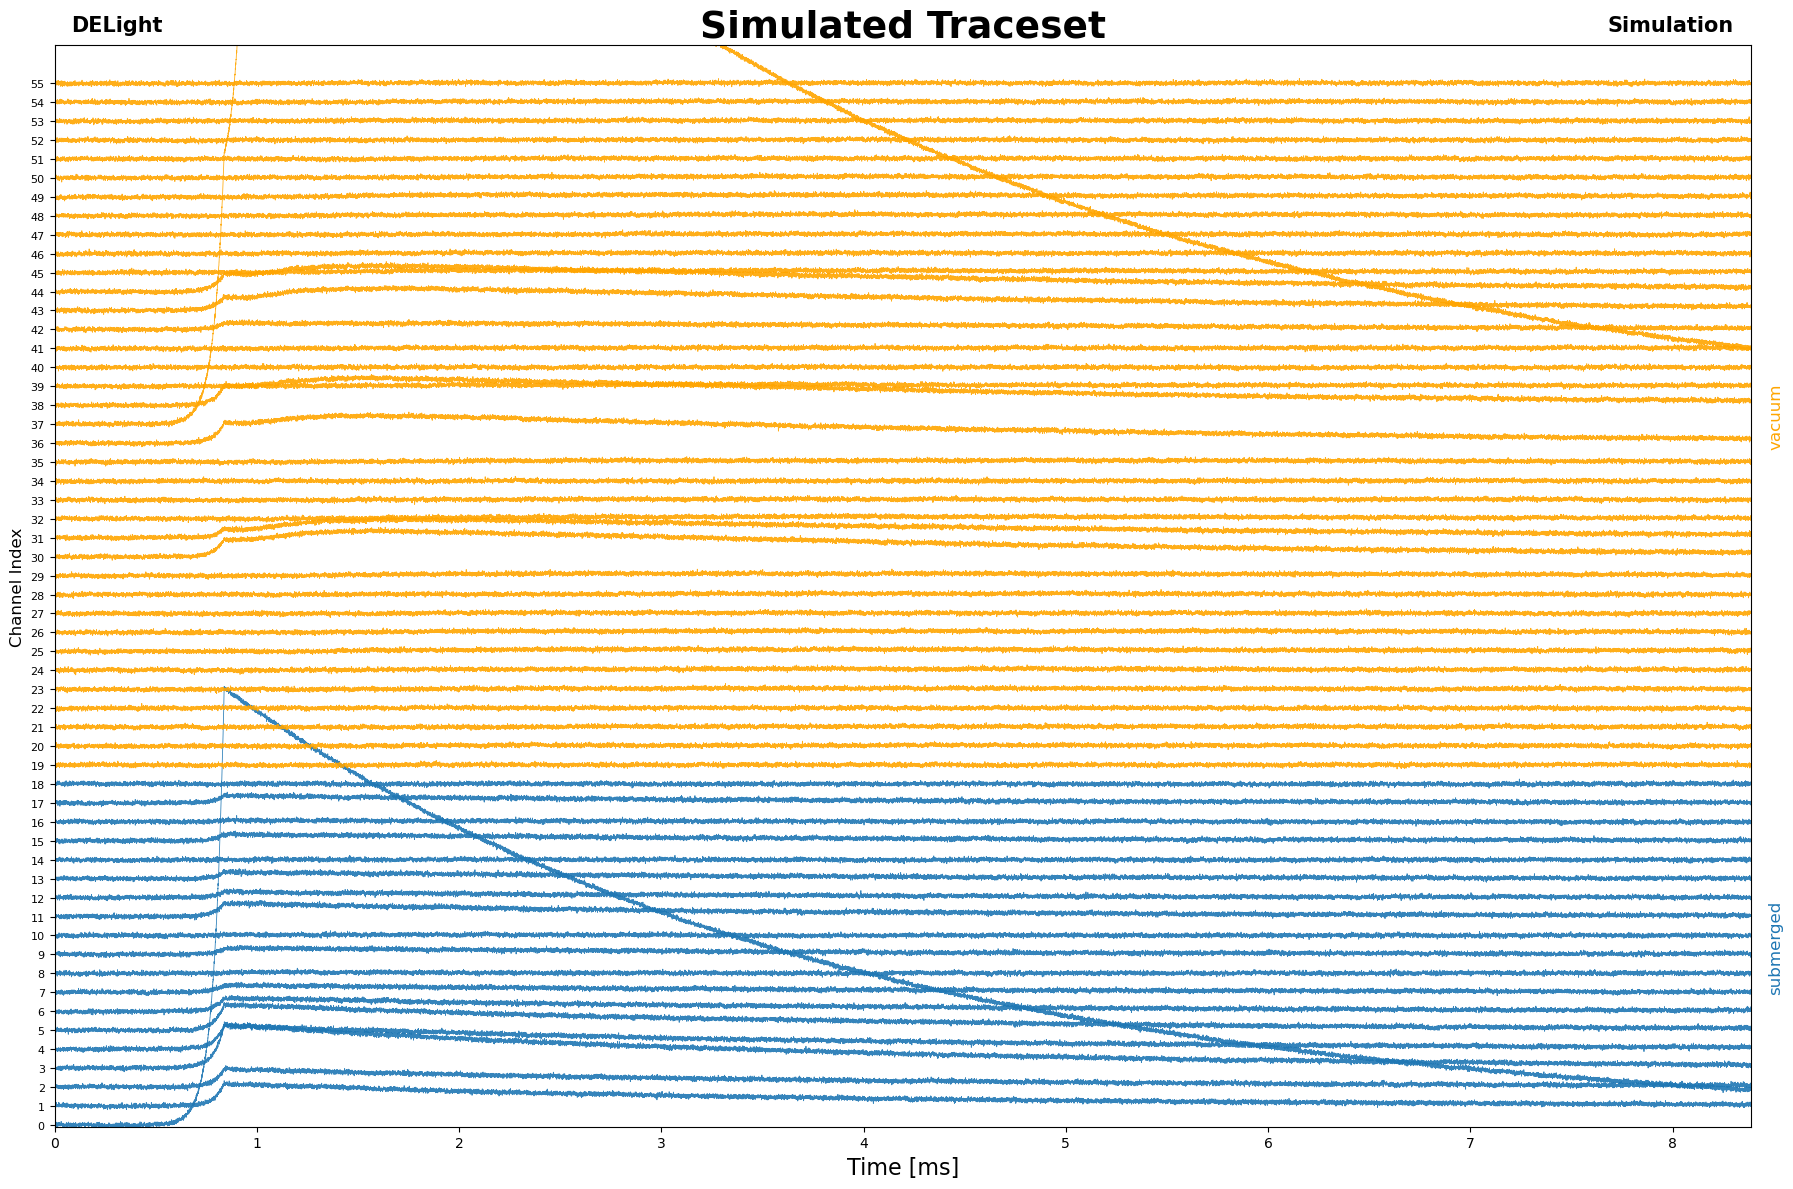

In [10]:
plot_traces(trace)

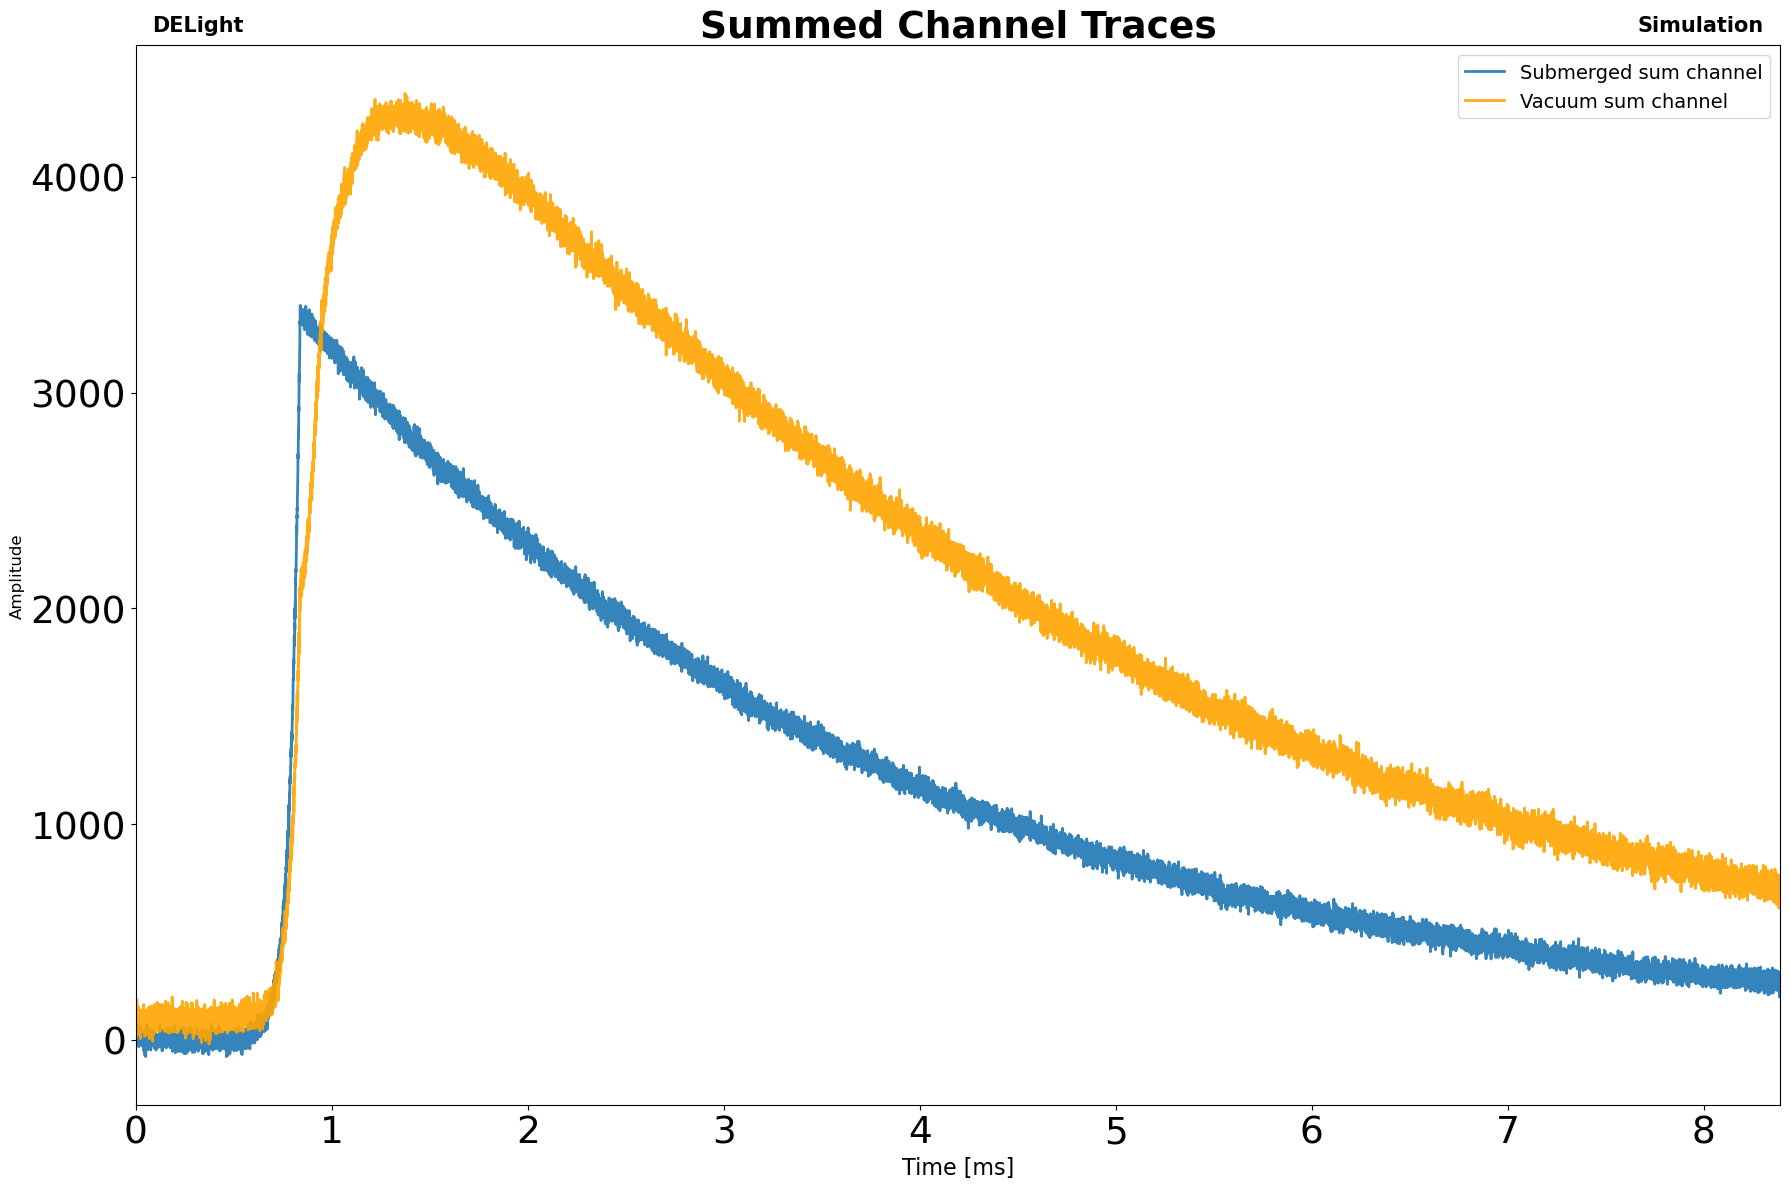

In [13]:
import numpy as np# Sum channels: (19, 32768) -> (1, 32768) and (37, 32768) -> (1, 32768)
submerged_sum = np.sum(trace[:19], axis=0, keepdims=True)  # sum of first 19 channels (blue)
vacuum_sum = np.sum(trace[19:56], axis=0, keepdims=True)   # sum of next 37 channels (orange)

fs = 3_906_250
time_ms = np.arange(submerged_sum.shape[1]) / fs * 1000

fig, ax = plt.subplots(figsize=(18, 12))

ax.plot(time_ms, submerged_sum[0], lw=2, color='tab:blue', label='Submerged sum channel', alpha=0.9)
ax.plot(time_ms, vacuum_sum[0] + 100, lw=2, color='orange', label='Vacuum sum channel', alpha=0.9)

ax.set_xlabel("Time [ms]", fontsize=16)
ax.set_ylabel("Amplitude", fontsize=12)
ax.set_title("Summed Channel Traces", fontsize=27, weight="bold")
ax.tick_params(axis='both', labelsize=27)
ax.set_xlim(0, time_ms[-1])
ax.legend(fontsize=14, loc='upper right')

# Top labels
ax.text(0.01, 1.01, 'DELight', transform=ax.transAxes, fontsize=15, weight='bold', va='bottom', ha='left', color='black')
ax.text(0.99, 1.01, 'Simulation', transform=ax.transAxes, fontsize=15, weight='bold', va='bottom', ha='right', color='black')

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_traces(traces, fs=3_906_250, offset_step=100, title="Simulated Traceset",
                vacuum_count=19, submerged_count=37):
    """Plot multi-channel traces stacked with channel indices on the left,
    color first `vacuum_count` channels orange and next `submerged_count` channels blue,
    and draw vertical labels on the right indicating the ranges."""
    # Handle 3D input shaped (1, C, S)
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    fig, ax = plt.subplots(figsize=(18, 12))

    for i in range(num_channels):
        if i < vacuum_count:
            color = 'tab:blue'
        elif i < vacuum_count + submerged_count:
            color = 'orange'
        else:
            color = 'gray'
        ax.plot(time_ms, traces[i] + i * offset_step, lw=0.6, color=color, alpha=0.9)

    # Left: channel indices as y-ticks aligned with each stacked trace
    y_ticks = [i * offset_step for i in range(num_channels)]
    y_labels = [str(i) for i in range(num_channels)]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels, fontsize=8)

    ax.set_xlabel("Time [ms]", fontsize=16)
    ax.set_ylabel("Channel Index", fontsize=12)
    ax.set_title(title, fontsize=27, weight="bold")
    ax.set_xlim(0, time_ms[-1])
    ax.set_ylim(-10, offset_step * (num_channels + 1))

    # Left top label: DELight
    ax.text(0.01, 1.01, 'DELight', transform=ax.transAxes, fontsize=15, weight='bold', va='bottom', ha='left', color='black')

    # Right shoulder label: Simulation
    ax.text(0.99, 1.01, 'Simulation', transform=ax.transAxes, fontsize=15, weight='bold', va='bottom', ha='right', color='black')

    # Right-side vertical labels indicating vacuum / submerged ranges
    def frac_for_channel(idx):
        # place fraction roughly centered for channel idx (avoid divide by zero)
        return (idx + 0.5) / max(1, (num_channels + 1))

    vac_end = min(vacuum_count, num_channels) - 1
    sub_start = vacuum_count
    sub_end = min(vacuum_count + submerged_count, num_channels) - 1

    if vac_end >= 0:
        vac_mid = (0 + vac_end) / 2.0
        vac_frac = frac_for_channel(vac_mid)
        ax.text(1.01, vac_frac, 'submerged', transform=ax.transAxes, rotation=90,
                va='center', ha='left', fontsize=12, color='tab:blue')

    if sub_start < num_channels and sub_end >= sub_start:
        sub_mid = (sub_start + sub_end) / 2.0
        sub_frac = frac_for_channel(sub_mid)
        ax.text(1.01, sub_frac, 'vacuum', transform=ax.transAxes, rotation=90,
                va='center', ha='left', fontsize=12, color='orange')

    plt.tight_layout()
    plt.show()

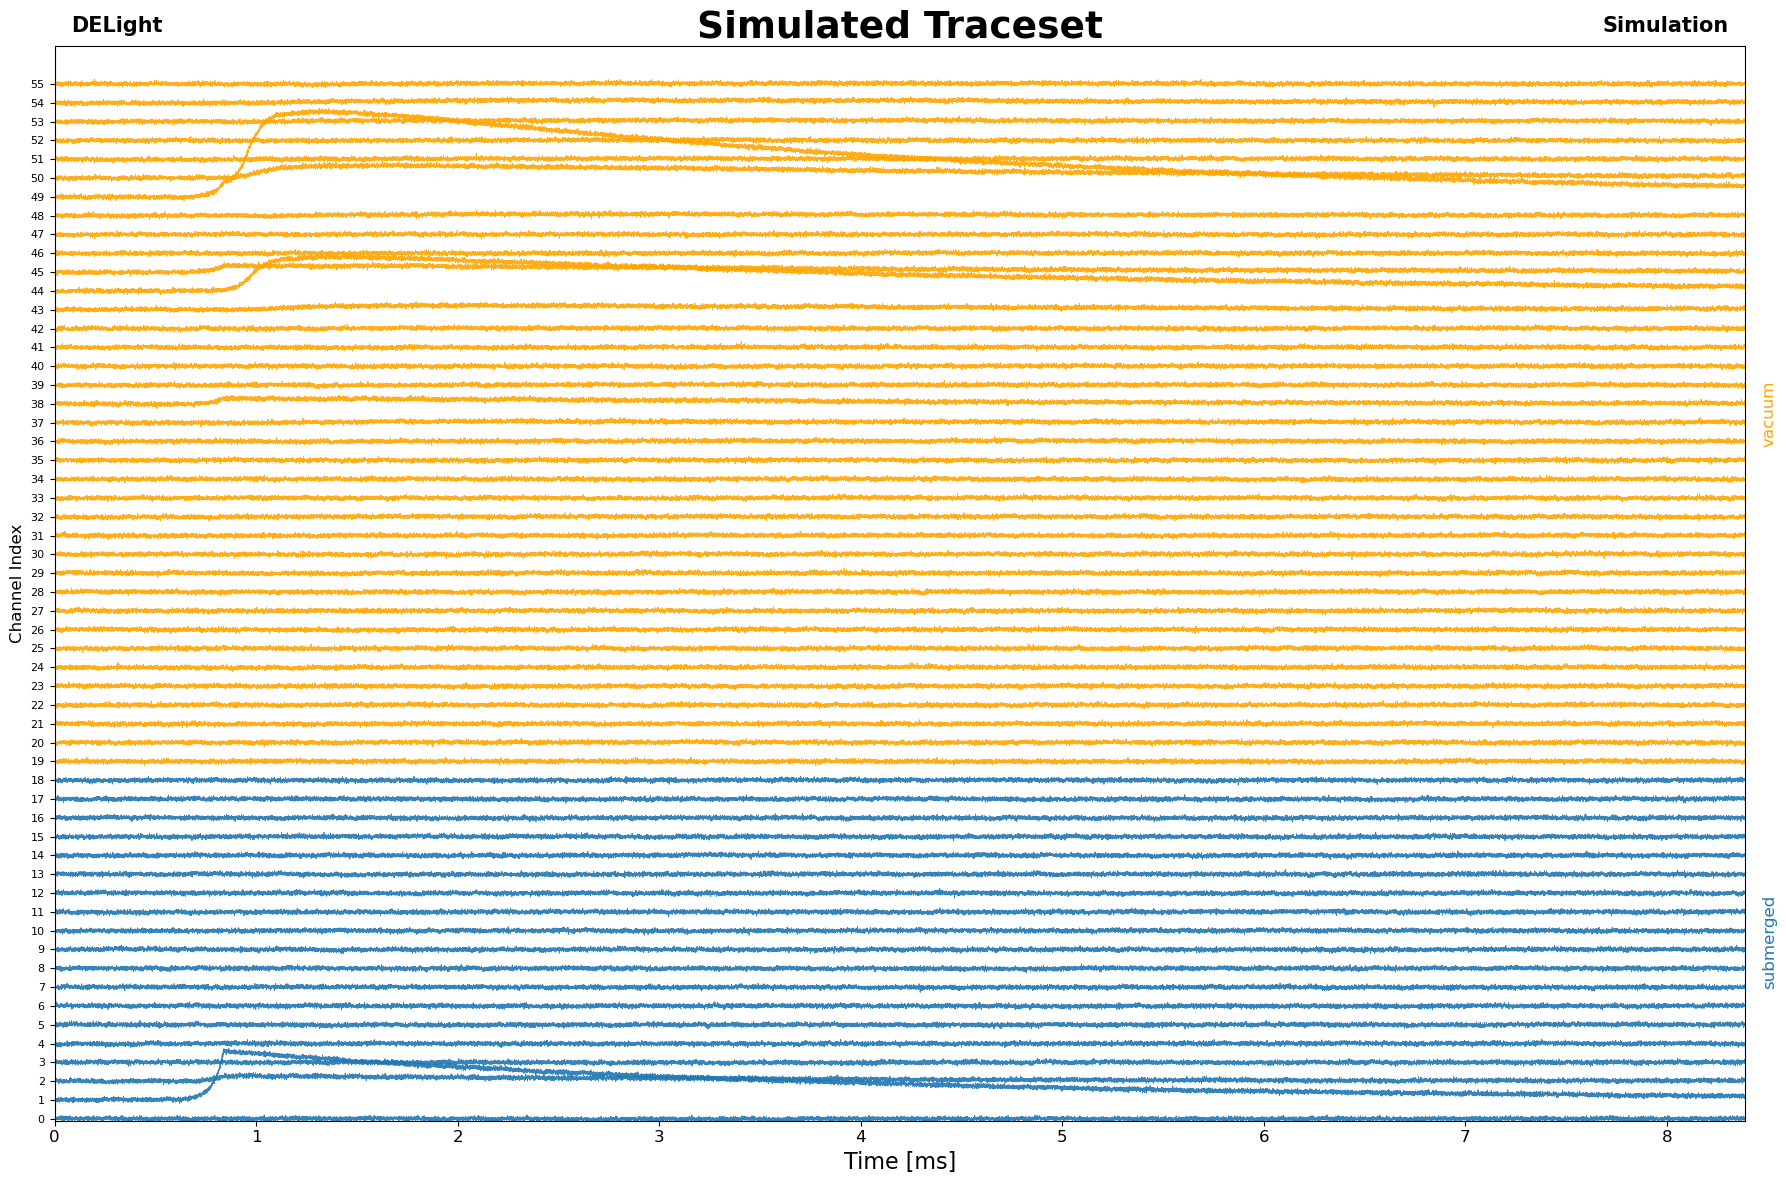

In [28]:
plot_traces(trace)

In [ ]:
import numpy as np# Sum channels: (19, 32768) -> (1, 32768) and (37, 32768) -> (1, 32768)
submerged_sum = np.sum(trace[:19], axis=0, keepdims=True)  # sum of first 19 channels (blue)
vacuum_sum = np.sum(trace[19:56], axis=0, keepdims=True)   # sum of next 37 channels (orange)

fs = 3_906_250
time_ms = np.arange(submerged_sum.shape[1]) / fs * 1000

fig, ax = plt.subplots(figsize=(18, 12))

ax.plot(time_ms, submerged_sum[0], lw=2, color='tab:blue', label='Submerged (ch 0-18)', alpha=0.9)
ax.plot(time_ms, vacuum_sum[0] + 100, lw=2, color='orange', label='Vacuum (ch 19-55)', alpha=0.9)

ax.set_xlabel("Time [ms]", fontsize=16)
ax.set_ylabel("Summed Amplitude", fontsize=12)
ax.set_title("Summed Channel Traces", fontsize=27, weight="bold")
ax.tick_params(axis='both', labelsize=14)
ax.set_xlim(0, time_ms[-1])
ax.legend(fontsize=14, loc='upper right')

# Top labels
ax.text(0.01, 1.01, 'DELight', transform=ax.transAxes, fontsize=15, weight='bold', va='bottom', ha='left', color='black')
ax.text(0.99, 1.01, 'Simulation', transform=ax.transAxes, fontsize=15, weight='bold', va='bottom', ha='right', color='black')

plt.tight_layout()
plt.show()


/tmp/ipykernel_1755307/1221963324.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


KeyboardInterrupt: 